## 1. Configuration & imports

Constants mirror the detection notebook (same dataset root, same CCPD resolution, same seeds) so the two notebooks stay consistent.

In [2]:
import os, math, random, time
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

random.seed(0); np.random.seed(0); torch.manual_seed(0)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

DATASET_ROOT = Path("Dataset")       
IMG_W, IMG_H = 720, 1160             

PLATE_W, PLATE_H = 94, 24

MAX_IMAGES     = 80000
MIN_PER_SUBSET = 300
TEST_FRAC      = 0.15      
VAL_FRAC       = 0.15    
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
print("CCPD root:", DATASET_ROOT.resolve(), "| exists:", DATASET_ROOT.exists())

def discover_subset(p: Path) -> str:
    try:
        rel = p.relative_to(DATASET_ROOT); parts = rel.parts
        return parts[0] if len(parts) > 1 else "unknown"
    except ValueError:
        return "unknown"


Device: cpu
CCPD root: C:\Users\marra\Desktop\GitHub\IS_Project\Dataset | exists: True


In [3]:
PROVINCES = ['皖','沪','津','渝','冀','晋','蒙','辽','吉','黑','苏','浙','京',
             '闽','赣','鲁','豫','鄂','湘','粤','桂','琼','川','贵','云','藏',
             '陕','甘','青','宁','新','警','学','O']            # 34
ALPHABETS = ['A','B','C','D','E','F','G','H','J','K','L','M','N',
             'P','Q','R','S','T','U','V','W','X','Y','Z','O']   # 25
ADS = ['A','B','C','D','E','F','G','H','J','K','L','M','N',
       'P','Q','R','S','T','U','V','W','X','Y','Z',
       '0','1','2','3','4','5','6','7','8','9','O']             # 35

def parse_ccpd_filename(path):
    name = Path(path).stem
    f = name.split('-')
    if len(f) != 7: return None
    f_area, f_tilt, f_bbox, f_verts, f_label, f_bright, f_blur = f
    try:
        (x1,y1),(x2,y2) = [tuple(map(int,p.split('&'))) for p in f_bbox.split('_')]
        verts = [tuple(map(int,p.split('&'))) for p in f_verts.split('_')]
        if len(verts) != 4: return None
        idxs = list(map(int, f_label.split('_')))
        if len(idxs) != 7: return None
        plate = PROVINCES[idxs[0]] + ALPHABETS[idxs[1]] + ''.join(ADS[i] for i in idxs[2:])
    except (ValueError, IndexError):
        return None
    return {"path": str(path), "bbox": (x1,y1,x2,y2), "vertices": verts, "plate": plate}

# ---- character vocabulary (union of all symbols that can appear) ----
VOCAB = PROVINCES[:-1] + [c for c in (ALPHABETS+ADS) if c != 'O'] + ['O']
VOCAB = list(dict.fromkeys(VOCAB))          # de-dup, keep order
char2idx = {c: i for i, c in enumerate(VOCAB)}
idx2char = {i: c for c, i in char2idx.items()}
NUM_CLASSES = len(VOCAB)                      # classes WITHOUT blank
BLANK_IDX   = NUM_CLASSES                      # CTC blank = last index
print(f"Vocabulary size: {NUM_CLASSES} chars (+1 CTC blank = {NUM_CLASSES+1})")

_t = "025-95_113-154&383_386&473-386&473_177&454_154&383_363&402-0_0_22_27_27_33_16-95-9.jpg"
print(parse_ccpd_filename(_t))


Vocabulary size: 68 chars (+1 CTC blank = 69)
{'path': '025-95_113-154&383_386&473-386&473_177&454_154&383_363&402-0_0_22_27_27_33_16-95-9.jpg', 'bbox': (154, 383, 386, 473), 'vertices': [(386, 473), (177, 454), (154, 383), (363, 402)], 'plate': '皖AY339S'}


In [4]:
def order_corners(pts):
    """Return the 4 points ordered TL, TR, BR, BL. Robust to input order."""
    pts = np.asarray(pts, dtype=np.float32)
    s = pts.sum(axis=1); d = np.diff(pts, axis=1).ravel()
    tl = pts[np.argmin(s)]; br = pts[np.argmax(s)]
    tr = pts[np.argmin(d)]; bl = pts[np.argmax(d)]
    return np.stack([tl, tr, br, bl]).astype(np.float32)

def _load_rgb(path):
    img = cv2.imread(str(path))                 # BGR
    if img is None:
        img = np.array(Image.open(path).convert("RGB"))[..., ::-1]  # fallback
    return img                                   # BGR uint8

def crop_box(path, rec, out_w=PLATE_W, out_h=PLATE_H):
    """Axis-aligned bbox crop -> resized RGB array (H,W,3)."""
    img = _load_rgb(path)
    x1, y1, x2, y2 = rec["bbox"]
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(img.shape[1], x2), min(img.shape[0], y2)
    if x2 <= x1 or y2 <= y1: return None
    crop = img[y1:y2, x1:x2]
    crop = cv2.resize(crop, (out_w, out_h), interpolation=cv2.INTER_LINEAR)
    return crop[..., ::-1]                        # BGR -> RGB

def crop_warp(path, rec, out_w=PLATE_W, out_h=PLATE_H):
    """Perspective-rectified crop from the 4 corners -> RGB array (H,W,3)."""
    img = _load_rgb(path)
    src = order_corners(rec["vertices"])          # TL,TR,BR,BL
    dst = np.array([[0,0],[out_w-1,0],[out_w-1,out_h-1],[0,out_h-1]], dtype=np.float32)
    M = cv2.getPerspectiveTransform(src, dst)
    warp = cv2.warpPerspective(img, M, (out_w, out_h), flags=cv2.INTER_LINEAR)
    return warp[..., ::-1]                         # BGR -> RGB

CROPPERS = {"box": crop_box, "warp": crop_warp}
print("Croppers ready:", list(CROPPERS))


Croppers ready: ['box', 'warp']


In [5]:
def gather_records(root, max_images, min_per_subset, seed=0):
    rng = random.Random(seed)
    by_subset = {}
    for p in root.rglob("*.jpg"):
        rec = parse_ccpd_filename(p)
        if rec is None: continue
        by_subset.setdefault(discover_subset(p), []).append(rec)
    for v in by_subset.values(): rng.shuffle(v)
    print("Subsets found:", {k: len(v) for k, v in by_subset.items()})

    total = sum(len(v) for v in by_subset.values())
    if max_images is None or max_images >= total:
        sampled = by_subset
    else:
        alloc = {k: min(min_per_subset, len(v)) for k, v in by_subset.items()}
        remaining = max_images - sum(alloc.values())
        if remaining > 0:
            leftover = {k: len(v)-alloc[k] for k, v in by_subset.items()}
            lt = sum(leftover.values())
            if lt > 0:
                for k in by_subset:
                    alloc[k] = min(len(by_subset[k]), alloc[k] + int(round(remaining*leftover[k]/lt)))
        sampled = {k: by_subset[k][:alloc[k]] for k in by_subset}
    return sampled

def split_records(sampled, test_frac, val_frac, seed=0):
    rng = random.Random(seed+1)
    train, val, test = [], [], []
    for k, v in sampled.items():
        v = list(v); rng.shuffle(v)
        n_test = int(round(len(v)*test_frac))
        n_val  = int(round(len(v)*val_frac))
        for r in v: r["subset"] = k
        test  += v[:n_test]
        val   += v[n_test:n_test+n_val]
        train += v[n_test+n_val:]
    rng.shuffle(train); rng.shuffle(val); rng.shuffle(test)
    return train, val, test

sampled = gather_records(DATASET_ROOT, MAX_IMAGES, MIN_PER_SUBSET, seed=0)
train_recs, val_recs, test_recs = split_records(sampled, TEST_FRAC, VAL_FRAC, seed=0)
print(f"\nSplit sizes -> train={len(train_recs):,}  val={len(val_recs):,}  test={len(test_recs):,}")
print("Test subset mix:", dict(Counter(r["subset"] for r in test_recs)))


Subsets found: {}

Split sizes -> train=0  val=0  test=0
Test subset mix: {}


In [6]:
def preview_crops(recs, n=5, seed=1):
    rng = random.Random(seed); rs = rng.sample(recs, min(n, len(recs)))
    fig, axes = plt.subplots(2, len(rs), figsize=(len(rs)*2.6, 3.4))
    for j, rec in enumerate(rs):
        b = crop_box(rec["path"], rec); w = crop_warp(rec["path"], rec)
        axes[0, j].imshow(b); axes[0, j].set_title(rec["plate"], fontsize=9); axes[0, j].axis("off")
        axes[1, j].imshow(w); axes[1, j].axis("off")
    axes[0, 0].set_ylabel("box");  axes[1, 0].set_ylabel("warp")
    fig.text(0.01, 0.72, "BOX",  rotation=90, va="center", fontsize=11)
    fig.text(0.01, 0.28, "WARP", rotation=90, va="center", fontsize=11)
    plt.suptitle("Top: axis-aligned box crop   |   Bottom: perspective-warped crop", y=1.02)
    plt.tight_layout(); plt.show()

preview_crops(train_recs, n=5)


ValueError: Number of columns must be a positive integer, not 0

<Figure size 0x374 with 0 Axes>

In [ ]:
def encode_ctc(plate):
    return [char2idx[c] for c in plate if c in char2idx]

def encode_fixed7(plate):
    if len(plate) != 7: return None
    if any(c not in char2idx for c in plate): return None
    return [char2idx[c] for c in plate]

class PlateDataset(Dataset):
    def __init__(self, recs, crop_mode="warp", label_mode="ctc", cache=True, augment=False):
        assert crop_mode in CROPPERS and label_mode in ("ctc", "fixed7")
        self.crop_mode, self.label_mode = crop_mode, label_mode
        self.cropper = CROPPERS[crop_mode]
        self.augment = augment
        self.cache = {} if cache else None
        # for fixed7, pre-filter to valid 7-char plates
        self.recs = []
        for r in recs:
            if label_mode == "fixed7" and encode_fixed7(r["plate"]) is None:
                continue
            self.recs.append(r)

    def __len__(self): return len(self.recs)

    def _get_crop(self, i, rec):
        if self.cache is not None and i in self.cache:
            return self.cache[i]
        crop = self.cropper(rec["path"], rec)
        if crop is None:
            crop = np.zeros((PLATE_H, PLATE_W, 3), dtype=np.uint8)
        if self.cache is not None:
            self.cache[i] = crop
        return crop

    def __getitem__(self, i):
        rec = self.recs[i]
        crop = self._get_crop(i, rec).astype(np.float32)
        if self.augment:
            # mild photometric jitter only (NO geometric flips: plate text is directional)
            crop *= np.random.uniform(0.85, 1.15)
            crop += np.random.uniform(-12, 12)
        crop = np.clip(crop, 0, 255)
        x = torch.from_numpy(crop).permute(2, 0, 1) / 127.5 - 1.0   # (3,H,W) in ~[-1,1]
        if self.label_mode == "ctc":
            y = torch.tensor(encode_ctc(rec["plate"]), dtype=torch.long)
            return x, y, len(y), rec["plate"]
        else:
            y = torch.tensor(encode_fixed7(rec["plate"]), dtype=torch.long)
            return x, y, 7, rec["plate"]

def ctc_collate(batch):
    xs, ys, lens, strs = zip(*batch)
    x = torch.stack(xs)
    y = torch.cat(ys)                       # concatenated targets for CTC
    target_lens = torch.tensor(lens, dtype=torch.long)
    return x, y, target_lens, list(strs)

def fixed_collate(batch):
    xs, ys, lens, strs = zip(*batch)
    return torch.stack(xs), torch.stack(ys), torch.tensor(lens), list(strs)

print("Dataset & collate fns ready.")


Dataset & collate fns ready.


In [ ]:
# ---------- 7a. LPRNet ----------
class SmallBasicBlock(nn.Module):
    """Bottleneck block from the LPRNet paper: 1x1 -> 3x1 -> 1x3 -> 1x1."""
    def __init__(self, cin, cout):
        super().__init__()
        c = cout // 4
        self.block = nn.Sequential(
            nn.Conv2d(cin, c, 1), nn.ReLU(inplace=True),
            nn.Conv2d(c, c, (3,1), padding=(1,0)), nn.ReLU(inplace=True),
            nn.Conv2d(c, c, (1,3), padding=(0,1)), nn.ReLU(inplace=True),
            nn.Conv2d(c, cout, 1),
        )
    def forward(self, x): return self.block(x)

class LPRNet(nn.Module):
    def __init__(self, n_classes, n_blank=1):
        super().__init__()
        self.total = n_classes + n_blank
        self.backbone = nn.Sequential(
            nn.Conv2d(3, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(3, (1,1), 1),
            SmallBasicBlock(64, 128), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(3, (2,1), 1),
            SmallBasicBlock(128, 256), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            SmallBasicBlock(256, 256), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d(3, (2,1), 1),
            nn.Dropout(0.3),
            nn.Conv2d(256, 256, (4,1)), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Dropout(0.3),
        )
        self.head = nn.Conv2d(256, self.total, 1)
        # KEY: bias the BLANK logit negative so CTC doesn't collapse to all-blank early.
        nn.init.constant_(self.head.bias[n_classes], -5.0)   # index n_classes == BLANK_IDX

    def forward(self, x):
        f = self.backbone(x)                 # (B, 256, h', W')
        f = F.adaptive_avg_pool2d(f, (1, f.size(3)))  # collapse height -> (B,256,1,W')
        logits = self.head(f).squeeze(2)     # (B, total, T)
        return logits.permute(2, 0, 1)       # (T, B, total)  <- CTC layout

# ---------- 7b. 7-head CNN ----------
class SevenHeadCNN(nn.Module):
    def __init__(self, n_classes, n_slots=7):
        super().__init__()
        self.n_slots = n_slots
        def blk(ci, co):
            return nn.Sequential(nn.Conv2d(ci, co, 3, 1, 1), nn.BatchNorm2d(co),
                                 nn.ReLU(inplace=True), nn.MaxPool2d(2))
        self.backbone = nn.Sequential(
            blk(3, 32), blk(32, 64), blk(64, 128),
            nn.AdaptiveAvgPool2d(1),         # -> (B,128,1,1)
        )
        self.heads = nn.ModuleList([nn.Linear(128, n_classes) for _ in range(n_slots)])

    def forward(self, x):
        f = self.backbone(x).flatten(1)      # (B,128)
        return torch.stack([h(f) for h in self.heads], dim=1)   # (B, 7, n_classes)

# ---------- 7c. CRNN (Convolutional Recurrent Neural Network) ----------
class CRNN(nn.Module):
    def __init__(self, n_classes, n_blank=1, hidden_size=256):
        super().__init__()
        self.total = n_classes + n_blank
        
        # 1. Feature Extraction (CNN)
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, 1, 1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(128, 256, 3, 1, 1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, 1, 1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d((2, 1), (2, 1)) 
        )
        
        # 2. Sequence Modeling (RNN)
        # L'input della LSTM sarà pari ai canali in uscita dalla CNN (256)
        self.rnn = nn.LSTM(
            input_size=256, 
            hidden_size=hidden_size, 
            num_layers=2, 
            bidirectional=True, 
            batch_first=False 
        )
        
        # 3. Transcription Head
        self.head = nn.Linear(hidden_size * 2, self.total)
        
        # KEY: Stesso trucco antiblocco CTC applicato alla CRNN
        nn.init.constant_(self.head.bias[n_classes], -5.0)

    def forward(self, x):
        f = self.cnn(x) # (B, 256, H', W')
        # Collassiamo l'altezza in modo dinamico per essere robusti a diverse size di crop (come in LPRNet)
        f = F.adaptive_avg_pool2d(f, (1, f.size(3))) # -> (B, 256, 1, W')
        
        # Prepariamo per la RNN: (Width, Batch, Features)
        f = f.squeeze(2).permute(2, 0, 1) # -> (W', B, 256) dove W' funge da asse temporale
        
        rnn_out, _ = self.rnn(f)
        logits = self.head(rnn_out) # -> (Time, Batch, Total_classes)
        return logits


# ---------- Model Size Summary ----------
lprnet_sizes = sum(p.numel() for p in LPRNet(NUM_CLASSES).parameters())
sevenhead_sizes = sum(p.numel() for p in SevenHeadCNN(NUM_CLASSES).parameters())
crnn_sizes = sum(p.numel() for p in CRNN(NUM_CLASSES).parameters())

print(f"LPRNet params:      {lprnet_sizes/1e6:.2f} M")
print(f"7-head CNN params:  {sevenhead_sizes/1e6:.2f} M")
print(f"CRNN params:        {crnn_sizes/1e6:.2f} M")




NameError: name 'nn' is not defined

In [ ]:
def ctc_greedy_decode(logits):
    """logits: (T,B,total) -> list[str]. Greedy: argmax, collapse repeats, drop blank."""
    pred = logits.argmax(dim=2).permute(1, 0).cpu().numpy()   # (B,T)
    out = []
    for seq in pred:
        s, prev = [], -1
        for t in seq:
            if t != prev and t != BLANK_IDX:
                s.append(idx2char.get(int(t), ""))
            prev = t
        out.append("".join(s))
    return out

def fixed_decode(logits):
    """logits: (B,7,n_classes) -> list[str]."""
    idx = logits.argmax(dim=2).cpu().numpy()
    return ["".join(idx2char.get(int(t), "") for t in row) for row in idx]

def score(preds, gts):
    full = sum(p == g for p, g in zip(preds, gts)) / max(1, len(gts))
    cc = tot = 0
    for p, g in zip(preds, gts):
        for i in range(min(len(p), len(g))):
            cc += (p[i] == g[i])
        tot += len(g)
    return full, (cc / max(1, tot))

# ---------- YOLO hook (for end-to-end eval; not used in the isolated recognizer eval) ----------
def crop_warp_from_corners(path, corners, out_w=PLATE_W, out_h=PLATE_H):
    """Same as crop_warp but takes EXTERNAL corners (e.g. YOLO predictions)
    instead of rec['vertices']. Swap this in for the end-to-end number."""
    img = _load_rgb(path)
    src = order_corners(corners)
    dst = np.array([[0,0],[out_w-1,0],[out_w-1,out_h-1],[0,out_h-1]], dtype=np.float32)
    M = cv2.getPerspectiveTransform(src, dst)
    return cv2.warpPerspective(img, M, (out_w, out_h), flags=cv2.INTER_LINEAR)[..., ::-1]

print("Decoders, metrics, and YOLO hook ready.")


Decoders, metrics, and YOLO hook ready.


In [ ]:
RUN_ROOT = Path("runs_plate_recog"); RUN_ROOT.mkdir(exist_ok=True)
EPOCHS   = 25
BATCH    = 128
LR       = 1e-3

def make_loaders(crop_mode, label_mode, batch=BATCH):
    collate = ctc_collate if label_mode == "ctc" else fixed_collate
    tr = PlateDataset(train_recs, crop_mode, label_mode, augment=True)
    va = PlateDataset(val_recs,   crop_mode, label_mode, augment=False)
    te = PlateDataset(test_recs,  crop_mode, label_mode, augment=False)
    dl = lambda ds, sh: DataLoader(ds, batch_size=batch, shuffle=sh, collate_fn=collate,
                                   num_workers=0, pin_memory=(DEVICE=="cuda"))
    return dl(tr, True), dl(va, False), dl(te, False), (len(tr), len(va), len(te))

@torch.no_grad()
def evaluate(model, loader, label_mode):
    model.eval(); preds, gts = [], []
    for batch in loader:
        x = batch[0].to(DEVICE); strs = batch[3]
        logits = model(x)
        preds += (ctc_greedy_decode(logits) if label_mode=="ctc" else fixed_decode(logits))
        gts += strs
    return score(preds, gts)

def train_lprnet(crop_mode, tag, epochs=EPOCHS):
    tr, va, te, sizes = make_loaders(crop_mode, "ctc")
    print(f"[{tag}] train/val/test = {sizes}")
    model = LPRNet(NUM_CLASSES).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=5e-4)   # CTC is collapse-prone; gentler LR than the 7-head
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    ctc = nn.CTCLoss(blank=BLANK_IDX, zero_infinity=True)
    hist, best_full, best_path = [], -1, RUN_ROOT/tag/"best.pt"; best_path.parent.mkdir(parents=True, exist_ok=True)
    for ep in range(epochs):
        model.train(); t0 = time.time()
        for x, y, tlens, _ in tr:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)                       # (T,B,total)
            logp = logits.log_softmax(2)
            T = logits.size(0)
            in_lens = torch.full((x.size(0),), T, dtype=torch.long)
            loss = ctc(logp, y, in_lens, tlens)
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
        sched.step()
        vf, vc = evaluate(model, va, "ctc")
        hist.append({"epoch":ep, "val_full":vf, "val_char":vc, "sec":round(time.time()-t0,1)})
        if vf > best_full:
            best_full = vf; torch.save(model.state_dict(), best_path)
        print(f"  ep{ep:02d} val_full={vf:.4f} val_char={vc:.4f} ({hist[-1]['sec']}s)")
        if ep % 5 == 0:   # diagnostic: see what CTC is actually decoding
            model.eval()
            with torch.no_grad():
                xb, _, _, sb = next(iter(va))
                dp = ctc_greedy_decode(model(xb.to(DEVICE)))
            print("      sample gt->pred:", [(g, p) for g, p in zip(sb[:3], dp[:3])])
    model.load_state_dict(torch.load(best_path))
    tf, tc = evaluate(model, te, "ctc")
    print(f"[{tag}] BEST val_full={best_full:.4f} | TEST full={tf:.4f} char={tc:.4f}")
    return model, pd.DataFrame(hist), {"tag":tag, "test_full":tf, "test_char":tc}

# --- NUOVA FUNZIONE PER LA CRNN ---
def train_crnn(crop_mode, tag, epochs=EPOCHS):
    tr, va, te, sizes = make_loaders(crop_mode, "ctc")
    print(f"[{tag}] train/val/test = {sizes}")
    model = CRNN(NUM_CLASSES).to(DEVICE)
    # Usiamo lo stesso LR di LPRNet per mantenere il benchmark equo
    opt = torch.optim.Adam(model.parameters(), lr=5e-4)   
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    ctc = nn.CTCLoss(blank=BLANK_IDX, zero_infinity=True)
    hist, best_full, best_path = [], -1, RUN_ROOT/tag/"best.pt"; best_path.parent.mkdir(parents=True, exist_ok=True)
    
    for ep in range(epochs):
        model.train(); t0 = time.time()
        for x, y, tlens, _ in tr:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)                       # (T,B,total)
            logp = logits.log_softmax(2)
            T = logits.size(0)
            in_lens = torch.full((x.size(0),), T, dtype=torch.long)
            loss = ctc(logp, y, in_lens, tlens)
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
        sched.step()
        
        vf, vc = evaluate(model, va, "ctc")
        hist.append({"epoch":ep, "val_full":vf, "val_char":vc, "sec":round(time.time()-t0,1)})
        if vf > best_full:
            best_full = vf; torch.save(model.state_dict(), best_path)
        print(f"  ep{ep:02d} val_full={vf:.4f} val_char={vc:.4f} ({hist[-1]['sec']}s)")
        if ep % 5 == 0:
            model.eval()
            with torch.no_grad():
                xb, _, _, sb = next(iter(va))
                dp = ctc_greedy_decode(model(xb.to(DEVICE)))
            print("      sample gt->pred:", [(g, p) for g, p in zip(sb[:3], dp[:3])])
            
    model.load_state_dict(torch.load(best_path))
    tf, tc = evaluate(model, te, "ctc")
    print(f"[{tag}] BEST val_full={best_full:.4f} | TEST full={tf:.4f} char={tc:.4f}")
    return model, pd.DataFrame(hist), {"tag":tag, "test_full":tf, "test_char":tc}

def train_sevenhead(crop_mode, tag, epochs=EPOCHS):
    tr, va, te, sizes = make_loaders(crop_mode, "fixed7")
    print(f"[{tag}] train/val/test = {sizes}  (7-char plates only)")
    model = SevenHeadCNN(NUM_CLASSES).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    ce = nn.CrossEntropyLoss()
    hist, best_full, best_path = [], -1, RUN_ROOT/tag/"best.pt"; best_path.parent.mkdir(parents=True, exist_ok=True)
    for ep in range(epochs):
        model.train(); t0 = time.time()
        for x, y, _, _ in tr:
            x, y = x.to(DEVICE), y.to(DEVICE)       # y: (B,7)
            logits = model(x)                        # (B,7,n_classes)
            loss = sum(ce(logits[:, s, :], y[:, s]) for s in range(7))
            opt.zero_grad(); loss.backward(); opt.step()
        sched.step()
        vf, vc = evaluate(model, va, "fixed7")
        hist.append({"epoch":ep, "val_full":vf, "val_char":vc, "sec":round(time.time()-t0,1)})
        if vf > best_full:
            best_full = vf; torch.save(model.state_dict(), best_path)
        print(f"  ep{ep:02d} val_full={vf:.4f} val_char={vc:.4f} ({hist[-1]['sec']}s)")
    model.load_state_dict(torch.load(best_path))
    tf, tc = evaluate(model, te, "fixed7")
    print(f"[{tag}] BEST val_full={best_full:.4f} | TEST full={tf:.4f} char={tc:.4f}")
    return model, pd.DataFrame(hist), {"tag":tag, "test_full":tf, "test_char":tc}

print("Training loops ready.")

Training loops ready.


In [ ]:
results = []
models  = {}

print("="*70, "\nLPRNet — BOX crops\n", "="*70)
models["lprnet_box"],  h_lb, r = train_lprnet("box",  "lprnet_box");   results.append(r)
print("="*70, "\nLPRNet — WARP crops\n", "="*70)
models["lprnet_warp"], h_lw, r = train_lprnet("warp", "lprnet_warp");  results.append(r)

print("="*70, "\n7-head CNN — BOX crops\n", "="*70)
models["seven_box"],   h_sb, r = train_sevenhead("box",  "seven_box"); results.append(r)
print("="*70, "\n7-head CNN — WARP crops\n", "="*70)
models["seven_warp"],  h_sw, r = train_sevenhead("warp", "seven_warp");results.append(r)

# --- ESECUZIONE NUOVO MODELLO ---
print("="*70, "\nCRNN — BOX crops\n", "="*70)
models["crnn_box"],    h_cb, r = train_crnn("box",  "crnn_box");       results.append(r)
print("="*70, "\nCRNN — WARP crops\n", "="*70)
models["crnn_warp"],   h_cw, r = train_crnn("warp", "crnn_warp");      results.append(r)

res_df = pd.DataFrame(results)
# Aggiorniamo le liste per mappare i 6 esperimenti eseguiti
res_df["model"] = ["LPRNet", "LPRNet", "7-head CNN", "7-head CNN", "CRNN", "CRNN"]
res_df["crop"]  = ["box", "warp", "box", "warp", "box", "warp"]
res_df = res_df[["model","crop","test_full","test_char","tag"]]

print("\n=== RECOGNITION RESULTS (frozen test set) ===")
display(res_df)
res_df.to_csv("plate_recognition_results.csv", index=False)
print("saved plate_recognition_results.csv")

LPRNet — BOX crops
[lprnet_box] train/val/test = (56003, 11999, 11999)
  ep00 val_full=0.0000 val_char=0.2165 (189.5s)
       sample gt->pred: [('皖AS9F17', '皖66'), ('皖A54E23', '皖66'), ('皖A27U20', '皖66')]
  ep01 val_full=0.0000 val_char=0.2570 (77.7s)
  ep02 val_full=0.0000 val_char=0.2928 (79.0s)
  ep03 val_full=0.0000 val_char=0.2871 (79.3s)
  ep04 val_full=0.0000 val_char=0.3047 (79.8s)
  ep05 val_full=0.0000 val_char=0.2968 (79.7s)
       sample gt->pred: [('皖AS9F17', '皖AY9008'), ('皖A54E23', '皖A08'), ('皖A27U20', '皖A9008')]
  ep06 val_full=0.0000 val_char=0.3027 (80.2s)
  ep07 val_full=0.0000 val_char=0.3095 (80.4s)
  ep08 val_full=0.0000 val_char=0.3052 (79.6s)
  ep09 val_full=0.0000 val_char=0.3069 (79.9s)
  ep10 val_full=0.0000 val_char=0.3028 (80.9s)
       sample gt->pred: [('皖AS9F17', '皖A0066'), ('皖A54E23', '皖A08'), ('皖A27U20', '皖A016')]
  ep11 val_full=0.0000 val_char=0.3089 (80.8s)
  ep12 val_full=0.0000 val_char=0.3042 (79.3s)
  ep13 val_full=0.0000 val_char=0.3039 (78.7s)
 

,model,crop,test_full,test_char,tag
0,LPRNet,box,0.000000,0.215577,lprnet_box
1,LPRNet,warp,0.000250,0.523079,lprnet_warp
2,7-head CNN,box,0.028252,0.651816,seven_box
3,7-head CNN,warp,0.416535,0.837748,seven_warp


saved plate_recognition_results.csv


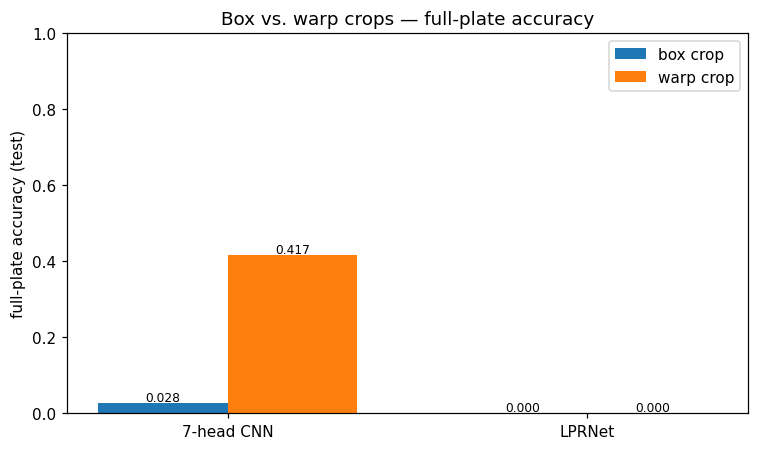


Warp uplift (warp - box), full-plate accuracy:
  7-head CNN  : +0.3883
  LPRNet      : +0.0003


In [ ]:
# Aumentata leggermente la figsize per accomodare 3 modelli
fig, ax = plt.subplots(figsize=(9, 4.5)) 
piv = res_df.pivot(index="model", columns="crop", values="test_full")
piv = piv[["box","warp"]]

x = np.arange(len(piv)); w = 0.36
ax.bar(x - w/2, piv["box"],  w, label="box crop")
ax.bar(x + w/2, piv["warp"], w, label="warp crop")

for i, m in enumerate(piv.index):
    for off, c in [(-w/2,"box"),(w/2,"warp")]:
        ax.text(i+off, piv.loc[m,c]+0.005, f"{piv.loc[m,c]:.3f}", ha="center", fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(piv.index)
ax.set_ylabel("full-plate accuracy (test)"); ax.set_ylim(0, 1.0)
ax.set_title("Box vs. warp crops — full-plate accuracy")
ax.legend(); plt.tight_layout(); plt.show()

print("\nWarp uplift (warp - box), full-plate accuracy:")
for m in piv.index:
    print(f"  {m:12s}: {piv.loc[m,'warp']-piv.loc[m,'box']:+.4f}")

In [ ]:
@torch.no_grad()
def eval_by_subset(model, crop_mode, label_mode):
    by = {}
    for r in test_recs: by.setdefault(r["subset"], []).append(r)
    rows = []
    collate = ctc_collate if label_mode=="ctc" else fixed_collate
    for subset, recs in sorted(by.items()):
        ds = PlateDataset(recs, crop_mode, label_mode, augment=False)
        if len(ds) == 0:
            rows.append({"subset":subset, "n":0, "full":np.nan, "char":np.nan}); continue
        dl = DataLoader(ds, batch_size=BATCH, shuffle=False, collate_fn=collate)
        preds, gts = [], []
        for batch in dl:
            logits = model(batch[0].to(DEVICE))
            preds += (ctc_greedy_decode(logits) if label_mode=="ctc" else fixed_decode(logits))
            gts += batch[3]
        f, c = score(preds, gts)
        rows.append({"subset":subset, "n":len(ds), "full":round(f,4), "char":round(c,4)})
    return pd.DataFrame(rows)

# best model = highest test_full; report its box-vs-warp per subset
best_row = res_df.loc[res_df["test_full"].idxmax()]
best_model_name = best_row["model"]
lm = "ctc" if best_model_name == "LPRNet" else "fixed7"
mb = "lprnet" if best_model_name == "LPRNet" else "seven"

sub_box  = eval_by_subset(models[f"{mb}_box"],  "box",  lm).rename(columns={"full":"full_box","char":"char_box"})
sub_warp = eval_by_subset(models[f"{mb}_warp"], "warp", lm).rename(columns={"full":"full_warp","char":"char_warp"})
sub = sub_box.merge(sub_warp[["subset","full_warp","char_warp"]], on="subset")
sub["warp_uplift_full"] = (sub["full_warp"] - sub["full_box"]).round(4)
print(f"Per-subset, best model = {best_model_name}:")
display(sub[["subset","n","full_box","full_warp","warp_uplift_full"]])
sub.to_csv("plate_recognition_by_subset.csv", index=False)
print("saved plate_recognition_by_subset.csv")


Per-subset, best model = 7-head CNN:


,subset,n,full_box,full_warp,warp_uplift_full
0,ccpd_base,6694,0.0433,0.6395,0.5962
1,ccpd_blur,721,0.0014,0.0361,0.0347
2,ccpd_challenge,1700,0.0065,0.0859,0.0794
3,ccpd_db,372,0.0108,0.0726,0.0618
4,ccpd_fn,733,0.0068,0.1787,0.1719
5,ccpd_rotate,370,0.0081,0.2000,0.1919
6,ccpd_tilt,1041,0.0010,0.1095,0.1085
7,ccpd_weather,368,0.0652,0.5408,0.4756


saved plate_recognition_by_subset.csv


/tmp/ipykernel_278329/23558637.py:19: UserWarning: Glyph 30358 (\N{CJK UNIFIED IDEOGRAPH-7696}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/home/luca/IS_Project/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30358 (\N{CJK UNIFIED IDEOGRAPH-7696}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


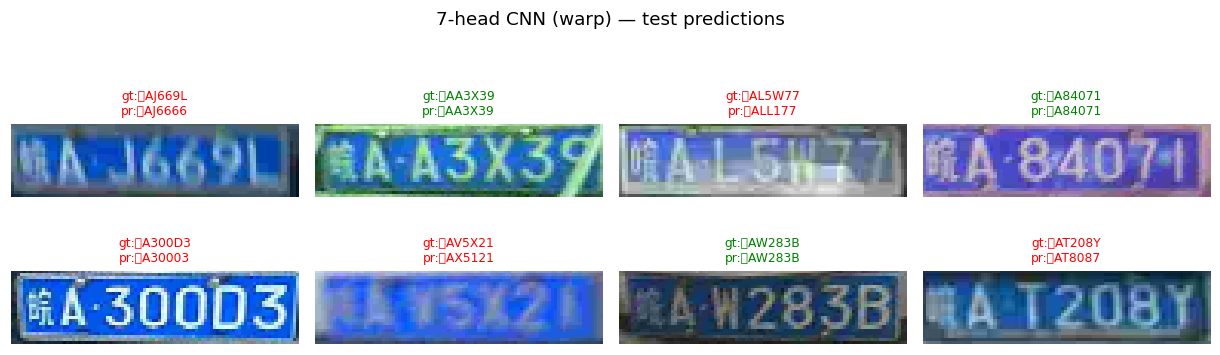

In [ ]:
@torch.no_grad()
def show_predictions(model, crop_mode, label_mode, n=8, seed=3):
    rng = random.Random(seed); rs = rng.sample(test_recs, n)
    model.eval()
    cols=4; rows=math.ceil(n/cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols*2.8, rows*1.8))
    axes = np.array(axes).reshape(-1)
    for ax, rec in zip(axes, rs):
        crop = CROPPERS[crop_mode](rec["path"], rec)
        x = (torch.from_numpy(crop.astype(np.float32)).permute(2,0,1)/127.5 - 1.0).unsqueeze(0).to(DEVICE)
        logits = model(x)
        pred = (ctc_greedy_decode(logits) if label_mode=="ctc" else fixed_decode(logits))[0]
        ok = (pred == rec["plate"])
        ax.imshow(crop)
        ax.set_title(f"gt:{rec['plate']}\npr:{pred}", color=("green" if ok else "red"), fontsize=8)
        ax.axis("off")
    for ax in axes[n:]: ax.axis("off")
    plt.suptitle(f"{best_model_name} (warp) — test predictions", y=1.02)
    plt.tight_layout(); plt.show()

show_predictions(models[f"{mb}_warp"], "warp", lm, n=8)


In [ ]:
for tag in ["lprnet_box","lprnet_warp","seven_box","seven_warp"]:
    p = RUN_ROOT/tag/"best.pt"
    print(f"  {'[x]' if p.exists() else '[ ]'} {p}")
print("\nCSVs:")
for f in ["plate_recognition_results.csv","plate_recognition_by_subset.csv"]:
    print(f"  {'[x]' if Path(f).exists() else '[ ]'} {f}")
